In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
ls

361654652_distribution_results.csv  362499770_distribution_results.csv
362236437_distribution_results.csv  362736713_distribution_results.csv
362345207_distribution_results.csv  charts_ssot.ipynb
362423278_distribution_results.csv  distortion_images/


In [3]:
# Output folder for charts
OUTPUT_FOLDER = "charts"

Path(OUTPUT_FOLDER).mkdir(exist_ok=True)


# Confidence Scores

In [4]:
df = pd.read_csv('362499770_distribution_results.csv')

In [5]:
df.head()

,trial,distortion_level,observation_id,actual_name,actual_species,top1_common_name,top1_genus,top1_species,top1_prob,top2_common_name,top2_genus,top2_species,top2_prob
0,10,0,362499770,California Sea Lion,Zalophus californianus,California Sea Lion,Zalophus,Zalophus californianus,95,Steller Sea Lion,Eumetopias,Eumetopias jubatus,10
1,9,0,362499770,California Sea Lion,Zalophus californianus,California Sea Lion,Zalophus,Zalophus californianus,95,Steller Sea Lion,Eumetopias,Eumetopias jubatus,15
2,1,0,362499770,California Sea Lion,Zalophus californianus,California Sea Lion,Zalophus,Zalophus californianus,95,Steller Sea Lion,Eumetopias,Eumetopias jubatus,20
3,5,0,362499770,California Sea Lion,Zalophus californianus,California Sea Lion,Zalophus,Zalophus californianus,95,Steller Sea Lion,Eumetopias,Eumetopias jubatus,10
4,12,0,362499770,California Sea Lion,Zalophus californianus,California Sea Lion,Zalophus,Zalophus californianus,95,Steller Sea Lion,Eumetopias,Eumetopias jubatus,10


In [6]:
def create_charts(file_path):
    df = pd.read_csv(file_path)

    # Ensure probability column is numeric
    df["top1_prob"] = pd.to_numeric(df["top1_prob"], errors="coerce")

    # Accuracy column
    df["accurate"] = (
        df["actual_species"].astype(str).str.lower().str.strip()
        ==
        df["top1_species"].astype(str).str.lower().str.strip()
    )

    # Remove missing rows
    df = df.dropna(subset=["top1_prob", "distortion_level"])

    # Base filename
    stem = file_path.replace('_distribution_results.csv', '')
    species = df['actual_name'].drop_duplicates().tolist()[0]

    # =====================================================
    # 1. HISTOGRAM
    # =====================================================

    plt.figure(figsize=(10, 6))

    #distortion_levels = sorted(df["distortion_level"].unique())
    distortion_levels = [0, 1, 3, 5]
    # SAME bins for all histograms
    bins = np.linspace(
        df["top1_prob"].min(),
        df["top1_prob"].max(),
        25
    )

    # Different colors automatically from seaborn palette
    colors = sns.color_palette("tab10", len(distortion_levels))

    for color, level in zip(colors, distortion_levels):

        subset = df[df["distortion_level"] == level]

        plt.hist(
            subset["top1_prob"],
            bins=bins,
            alpha=0.5,
            label=f"Distortion {level}",
            color=color,
            edgecolor="black"
        )

    plt.xlabel("Top-1 Probability")
    plt.ylabel("Count")
    plt.title(f"Distribution of Top-1 Probability\n{stem} - {species}")

    plt.legend(title="Distortion Level")

    hist_output = Path(OUTPUT_FOLDER) / f"{stem}_histogram.png"

    plt.savefig(hist_output, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()

    # =====================================================
    # 2. DUAL-AXIS LINE CHART
    # =====================================================

    summary = (
        df.groupby("distortion_level")
        .agg(
            avg_top1_prob=("top1_prob", "mean"),
            accuracy=("accurate", "mean")
        )
        .reset_index()
        .sort_values("distortion_level")
    )

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # LEFT AXIS
    line1 = ax1.plot(
        summary["distortion_level"],
        summary["avg_top1_prob"],
        marker="o",
        linewidth=2,
        color="blue",
        label="Average Top-1 Probability"
    )

    ax1.set_xlabel("Distortion Level")
    ax1.set_ylabel("Average Top-1 Probability", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")

    # RIGHT AXIS
    ax2 = ax1.twinx()

    line2 = ax2.plot(
        summary["distortion_level"],
        summary["accuracy"],
        marker="s",
        linewidth=2,
        color="red",
        label="Accuracy"
    )

    ax2.set_ylabel("Accuracy", color="red")
    ax2.tick_params(axis="y", labelcolor="red")

    # Combined legend
    lines = line1 + line2
    labels = [line.get_label() for line in lines]

    ax1.legend(lines, labels, loc="best")

    plt.title(f"Average Top-1 Probability and Accuracy\n{stem} - {species}")

    line_output = Path(OUTPUT_FOLDER) / f"{stem}_dual_axis.png"

    plt.savefig(line_output, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()

    print(f"Saved:")
    print(f"  {hist_output}")
    print(f"  {line_output}")


362499770


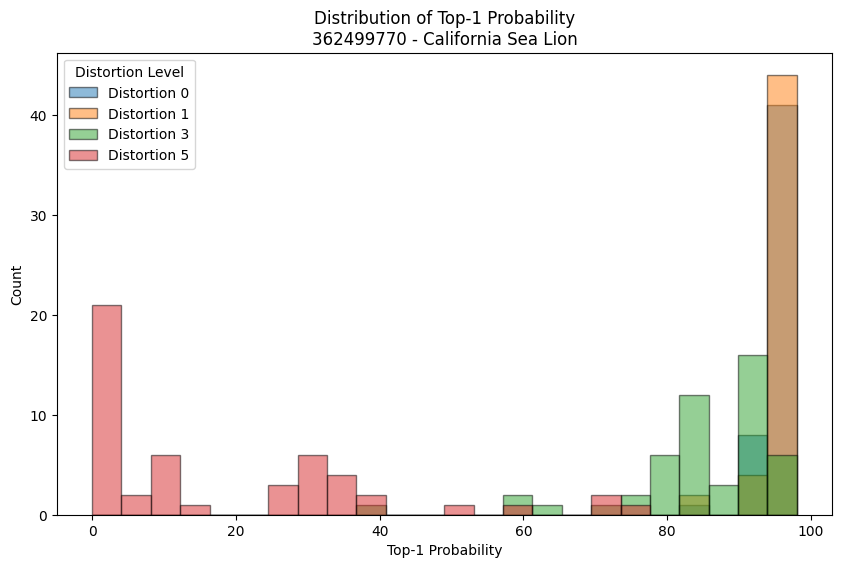

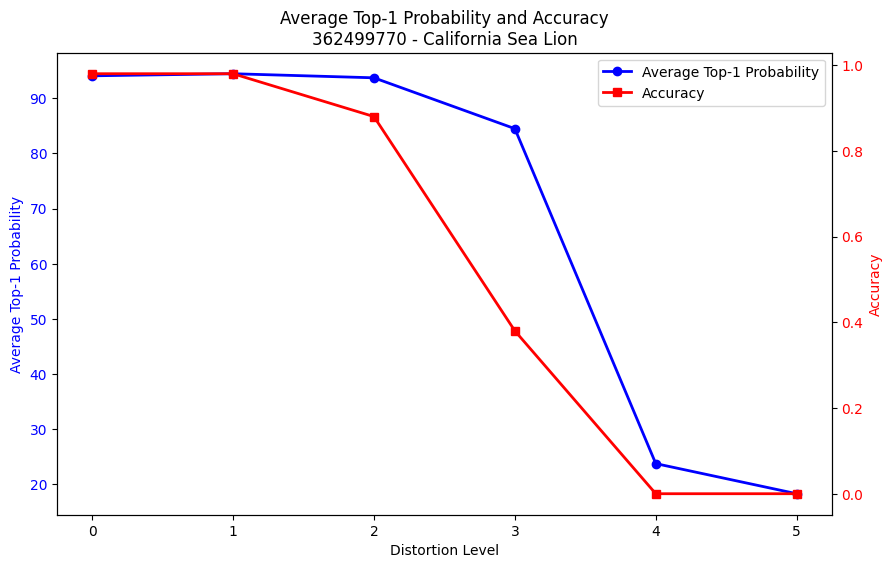

Saved:
  charts/362499770_histogram.png
  charts/362499770_dual_axis.png




362345207


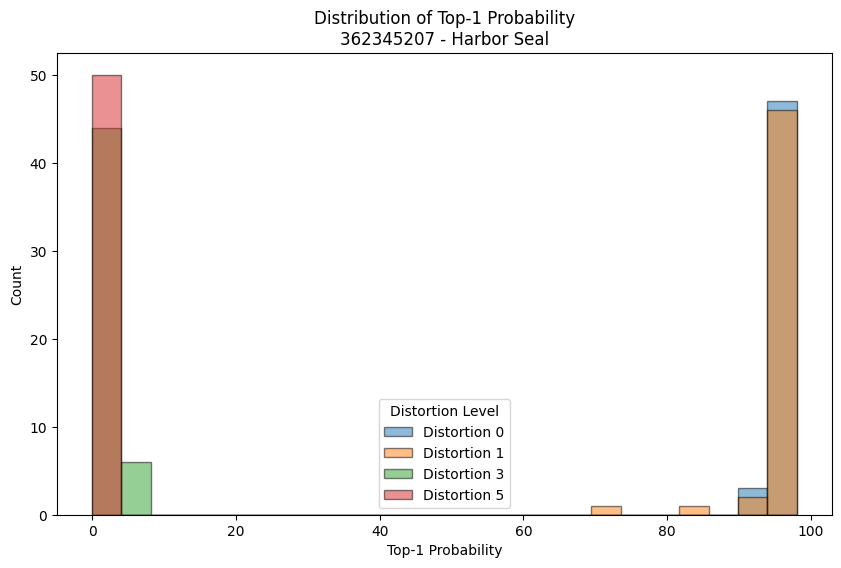

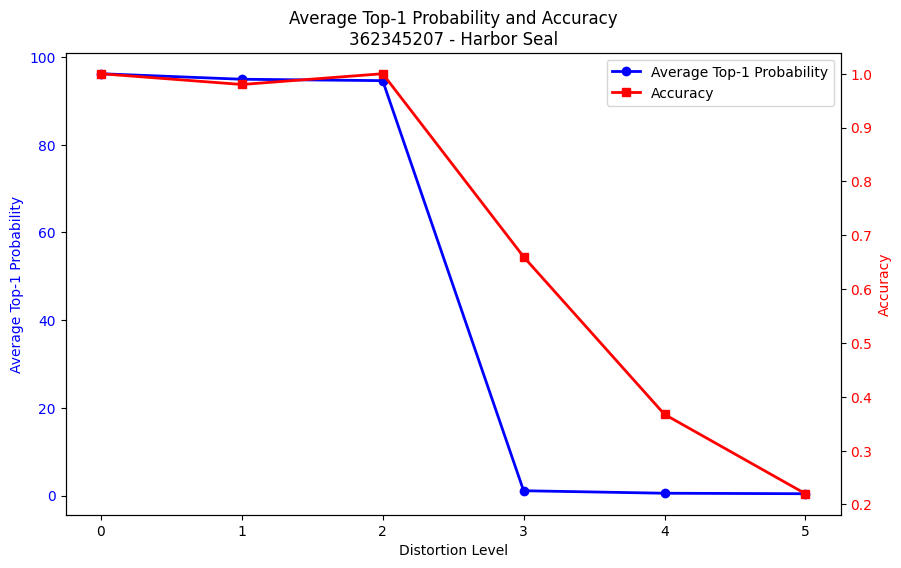

Saved:
  charts/362345207_histogram.png
  charts/362345207_dual_axis.png




362423278


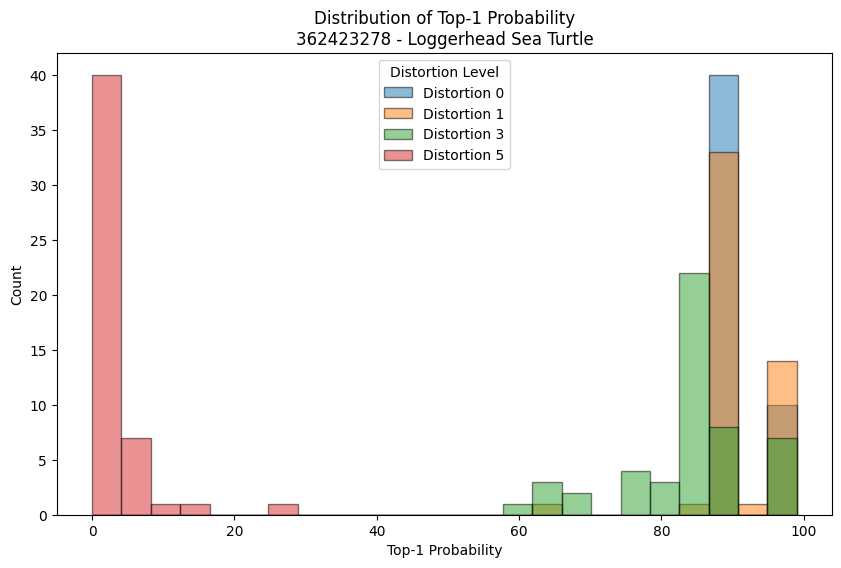

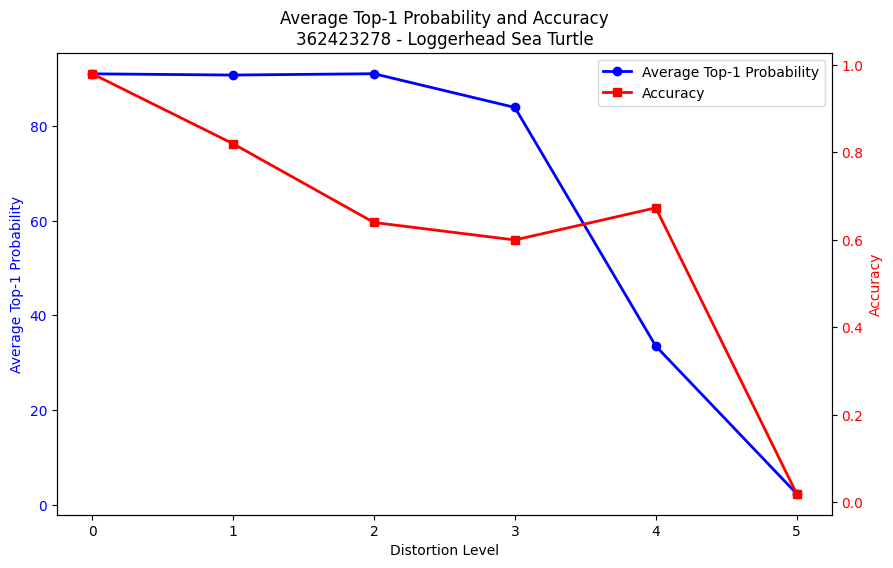

Saved:
  charts/362423278_histogram.png
  charts/362423278_dual_axis.png




361654652


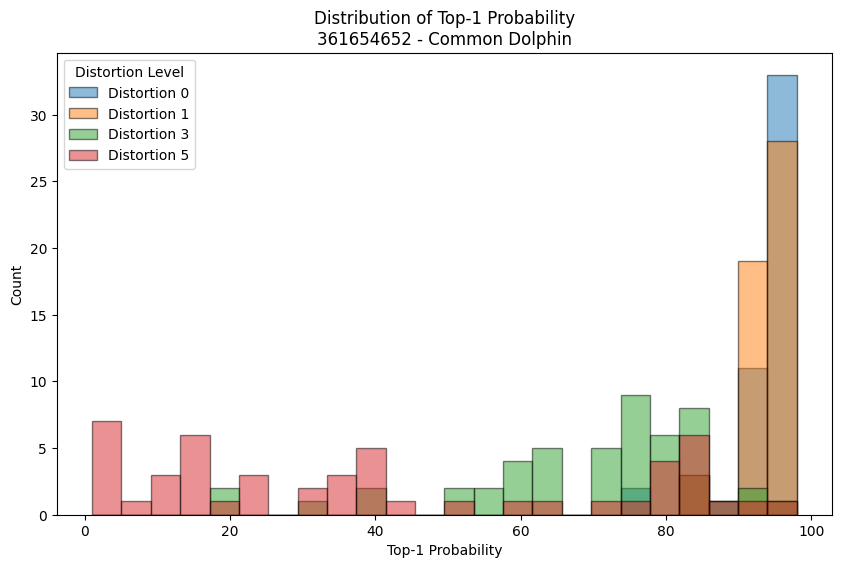

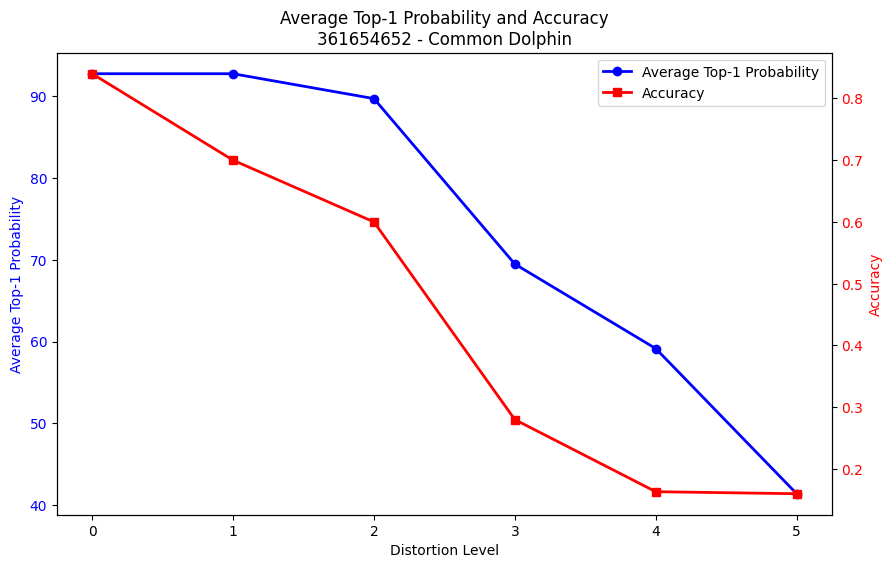

Saved:
  charts/361654652_histogram.png
  charts/361654652_dual_axis.png




362736713


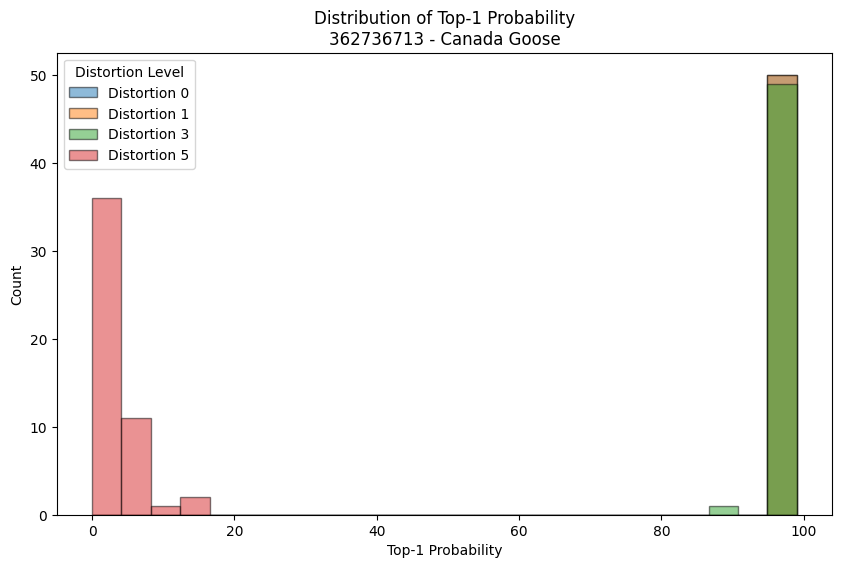

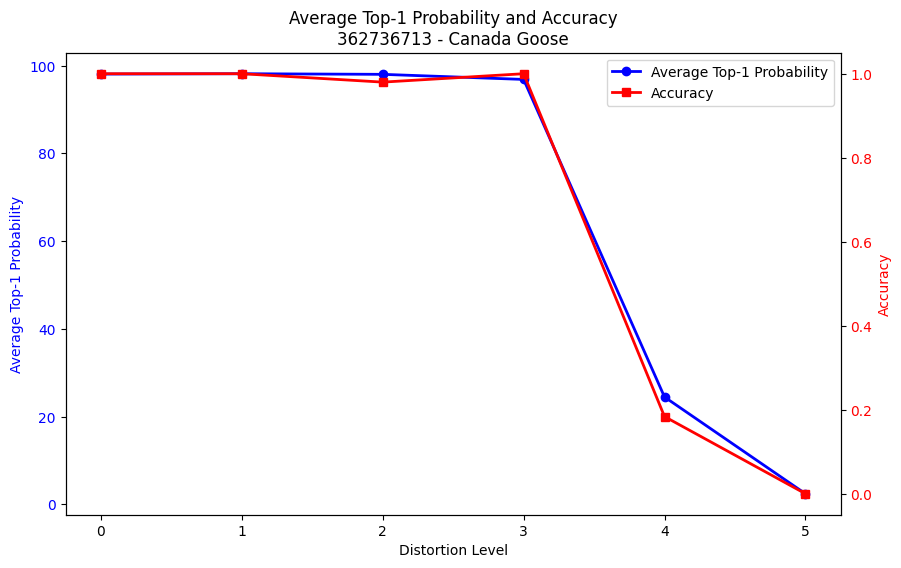

Saved:
  charts/362736713_histogram.png
  charts/362736713_dual_axis.png




362236437


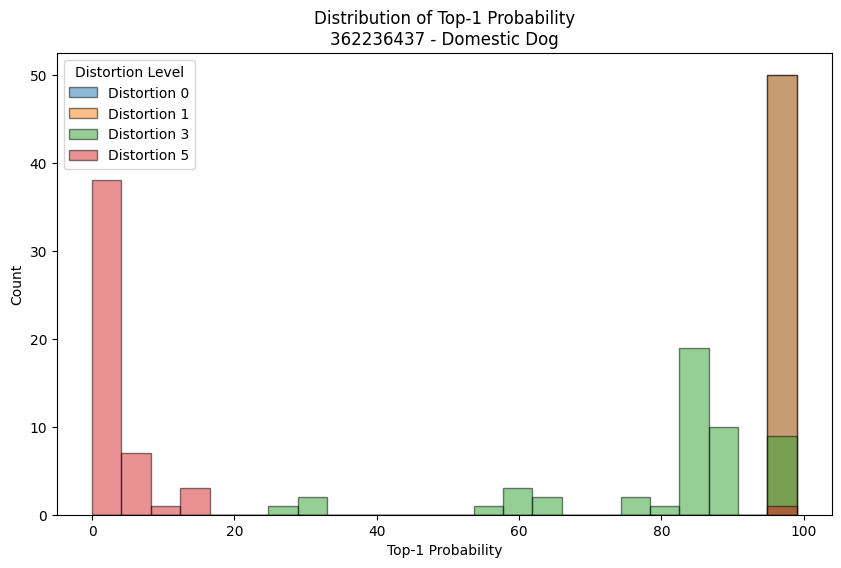

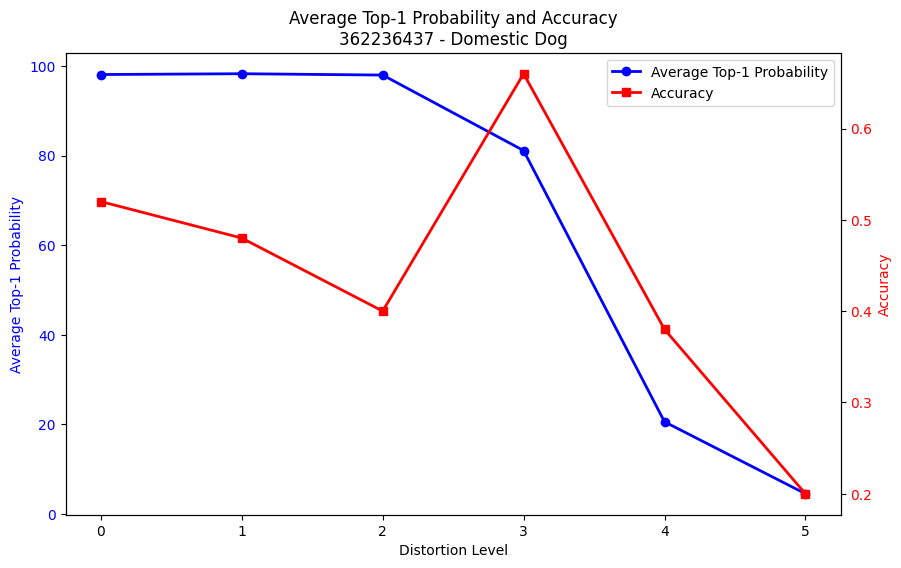

Saved:
  charts/362236437_histogram.png
  charts/362236437_dual_axis.png






In [7]:
TARGET_IDS = [362499770, 362345207, 362423278, 361654652, 362736713, 362236437]

for i in TARGET_IDS:
    print(i)
    create_charts(f'{i}_distribution_results.csv')
    print('\n')
    print('\n')

In [55]:
file_path = 'all_images_distortion_results.csv'